# Real-data Inventory Optimization 
### Walmart M5 sales → Weekly Forecasting → Uncertainty Scenarios → Gurobi MILP → OR-Tools MILP → Holdout Evaluation

**Scope:** A single store, six SKU–store series, 64 training + 6 chronologically held-out weeks. The plan commits all six weeks' orders before learning future demand; deliveries are assumed to arrive at the start of each designated week.

**Provenance:** Historical weekly *sales* come from M5, and are used as a **proxy for demand**. Prices, actual purchasing costs, stock levels, order lead times and warehouse capacities are **not provided** here by M5; the model's operating parameters are transparent **illustrative assumptions**. The future demand scenarios are generated from training-period forecast errors, **not directly observed possible futures**.

In [1]:
from pathlib import Path
import json
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RAW_DIR = PROJECT_ROOT / 'raw_data' / 'm5'
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
for directory in (RAW_DIR, DATA_DIR, RESULTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SETTINGS = {
    'seed': 20260920, 'store_id': 'CA_1', 'n_skus': 6,
    'train_weeks': 64, 'holdout_weeks': 6, 'horizon': 6,
    'n_scenarios': 16, 'service_level': 0.95,
    'time_limit_seconds': 120
}
SEED = SETTINGS['seed']
STORE_ID = SETTINGS['store_id']
N_SKUS = SETTINGS['n_skus']
TRAIN_WEEKS = SETTINGS['train_weeks']
HOLDOUT_WEEKS = SETTINGS['holdout_weeks']
HORIZON = SETTINGS['horizon']
N_SCENARIOS = SETTINGS['n_scenarios']
SERVICE_LEVEL = SETTINGS['service_level']
TIME_LIMIT_SECONDS = SETTINGS['time_limit_seconds']
M5_FILE = RAW_DIR / 'sales_train_validation.csv'
print('M5 CSV available:', M5_FILE.is_file())

M5 CSV available: True


### Read M5 sales 

In [2]:
header = pd.read_csv(M5_FILE, nrows=0).columns.tolist()
all_day_cols = sorted([c for c in header if c.startswith('d_') and c[2:].isdigit()], key=lambda c: int(c[2:]))
required_days = (TRAIN_WEEKS + HOLDOUT_WEEKS) * 7
if not {'id','store_id'}.issubset(header) or len(all_day_cols) < required_days:
    raise ValueError('M5 file must have id, store_id and at least 490 d_# columns.')
selected_day_cols = all_day_cols[-required_days:]
usecols = ['id', 'store_id'] + selected_day_cols
parts = []
for chunk in pd.read_csv(M5_FILE, usecols=usecols, chunksize=3000):
    subset = chunk.loc[chunk['store_id'].eq(STORE_ID)]
    if not subset.empty:
        parts.append(subset)
if not parts:
    raise ValueError(f'Store {STORE_ID} not found; check the file or change STORE_ID.')
store_sales = pd.concat(parts, ignore_index=True)
print(f'Store {STORE_ID} has {len(store_sales):,} SKU series in this extract.')
print('Day columns:', selected_day_cols[0], 'through', selected_day_cols[-1])
display(store_sales.iloc[:3, :8])

Store CA_1 has 3,049 SKU series in this extract.
Day columns: d_1424 through d_1913


,id,store_id,d_1424,d_1425,d_1426,d_1427,d_1428,d_1429
0,HOBBIES_1_001_CA_1_validation,CA_1,0,1,0,0,1,1
1,HOBBIES_1_002_CA_1_validation,CA_1,2,3,3,0,1,0
2,HOBBIES_1_003_CA_1_validation,CA_1,0,0,0,0,1,0


### Select reasonably active SKUs using only the final 26 training weeks.

In [3]:
train_day_cols = selected_day_cols[:TRAIN_WEEKS * 7]
selection_window = train_day_cols[-26 * 7:]
store_sales = store_sales.copy()
store_sales['selection_training_sales'] = store_sales[selection_window].sum(axis=1)
chosen = (store_sales.loc[store_sales['selection_training_sales'] > 0]
          .sort_values('selection_training_sales', ascending=False)
          .head(N_SKUS).copy())
if len(chosen) != N_SKUS:
    raise ValueError('Insufficient nonzero-selling SKU series in the selected store.')
print('Selected series (without inspecting holdout days):')
display(chosen[['id','store_id','selection_training_sales']])

Selected series (without inspecting holdout days):


,id,store_id,selection_training_sales
2314,FOODS_3_090_CA_1_validation,CA_1,8262
2810,FOODS_3_586_CA_1_validation,CA_1,6812
2476,FOODS_3_252_CA_1_validation,CA_1,6133
2344,FOODS_3_120_CA_1_validation,CA_1,5589
2288,FOODS_3_064_CA_1_validation,CA_1,4517
2811,FOODS_3_587_CA_1_validation,CA_1,4516


## Convert daily sales into non-overlapping weekly buckets

For SKU `i` and week `t`: $D_{it}=\sum_{d\in\text{week }t}\mathrm{sales}_{id}$. Week indices **0–63** are training and **64–69** are held out. We relabel held-out weeks **0–5** so the prediction and optimization period use the same time index. These are **observed sales**, not known true customer demand.

In [4]:
rows = []
for row in chosen.itertuples(index=False):
    values = np.asarray([getattr(row, c) for c in selected_day_cols], dtype=float)
    if not np.isfinite(values).all() or (values < 0).any():
        raise ValueError('Missing, infinite or negative sales found.')
    weekly = values.reshape(TRAIN_WEEKS + HOLDOUT_WEEKS, 7).sum(axis=1)
    for t, observed_sales in enumerate(weekly):
        rows.append({'sku': str(row.id), 'week': t, 'demand': int(round(observed_sales))})
historical = pd.DataFrame(rows).sort_values(['sku','week']).reset_index(drop=True)
train_weekly = historical.loc[historical['week'] < TRAIN_WEEKS].copy()
holdout = historical.loc[historical['week'] >= TRAIN_WEEKS].copy()
holdout['week'] -= TRAIN_WEEKS
assert len(historical) == N_SKUS * (TRAIN_WEEKS + HOLDOUT_WEEKS)
assert len(holdout) == N_SKUS * HOLDOUT_WEEKS
print('Training observations:', len(train_weekly))
display(train_weekly.head(8))
print('Holdout observations:', len(holdout))
display(holdout.head(8))

Training observations: 384


,sku,week,demand
0,FOODS_3_064_CA_1_validation,0,90
1,FOODS_3_064_CA_1_validation,1,71
2,FOODS_3_064_CA_1_validation,2,147
3,FOODS_3_064_CA_1_validation,3,127
4,FOODS_3_064_CA_1_validation,4,153
5,FOODS_3_064_CA_1_validation,5,144
6,FOODS_3_064_CA_1_validation,6,67
7,FOODS_3_064_CA_1_validation,7,186


Holdout observations: 36


,sku,week,demand
64,FOODS_3_064_CA_1_validation,0,164
65,FOODS_3_064_CA_1_validation,1,160
66,FOODS_3_064_CA_1_validation,2,153
67,FOODS_3_064_CA_1_validation,3,171
68,FOODS_3_064_CA_1_validation,4,182
69,FOODS_3_064_CA_1_validation,5,225
134,FOODS_3_090_CA_1_validation,0,356
135,FOODS_3_090_CA_1_validation,1,427


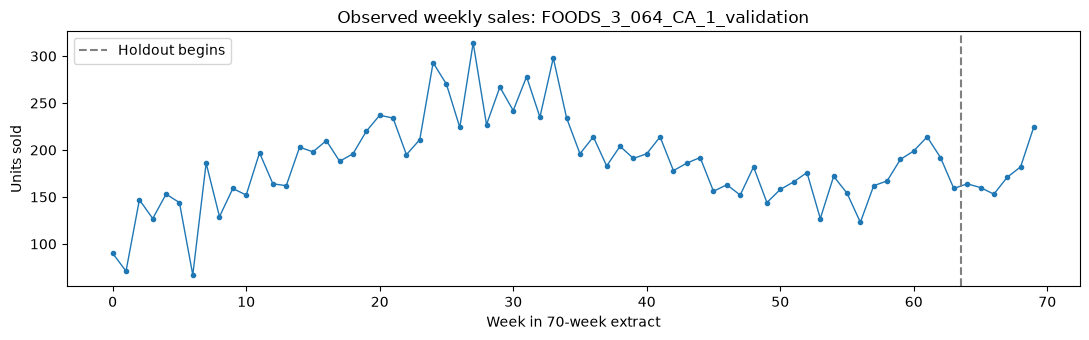

In [5]:
# Show historical weekly sales for the first SKU.
first_sku = sorted(historical['sku'].unique())[0]
series = historical.loc[historical['sku'].eq(first_sku)].sort_values('week')
plt.figure(figsize=(11,3.5))
plt.plot(series['week'], series['demand'], marker='.', linewidth=1)
plt.axvline(TRAIN_WEEKS - 0.5, color='gray', linestyle='--', label='Holdout begins')
plt.title(f'Observed weekly sales: {first_sku}')
plt.xlabel('Week in 70-week extract'); plt.ylabel('Units sold'); plt.legend(); plt.tight_layout(); plt.show()

## Save outputs

In [6]:
(DATA_DIR/'project_settings.json').write_text(json.dumps(SETTINGS, indent=2)+'\n',encoding='utf-8')
historical.to_csv(DATA_DIR/'historical_weekly.csv', index=False)
train_weekly.to_csv(DATA_DIR/'train_weekly.csv', index=False)
holdout.to_csv(DATA_DIR/'holdout_actual.csv', index=False)
print('Saved historical_weekly.csv, train_weekly.csv, holdout_actual.csv and project_settings.json.')

Saved historical_weekly.csv, train_weekly.csv, holdout_actual.csv and project_settings.json.
